In [1]:
import pandas as pd
import numpy as np
import matplotlib
# make font nicer for adobe illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("ReportInfectionStatsMalaria (3).csv")

In [3]:
df.head()

,Time,NodeID,IndividualID,Gender,AgeYears,InfectionID,Infectiousness,Duration,Hepatocytes,IRBCs,Gametocytes
0,18250,1,12845,M,41.87400,465441,0.000000,1,2,0,0
1,18250,1,16754,F,30.60270,462944,0.000855,126,0,477,1007401
2,18250,1,18089,M,26.86300,460201,0.000080,249,0,57544004,319690
3,18250,1,13,M,54.55590,464321,0.011124,59,0,26362902259,71100043
4,18250,1,24684,M,8.05479,465199,0.000000,14,0,170465866,0


In [4]:
# Groupby Infection ID, and compute mean infectiousness, std infectiousness, mean gametocytes, std gametocytes
foo = df.groupby("InfectionID").agg({"Infectiousness": ["mean", "std"], "Gametocytes": ["mean", "std"]})
foo.head()

Infectiousness             Gametocytes              
                      mean       std          mean           std
InfectionID                                                     
456218            0.000257  0.000349  3.959407e+05  5.444591e+05
456622            0.278177  0.250248  1.052803e+06  8.669385e+05
456923            0.000989  0.000762  1.303222e+06  1.077585e+06
457261            0.000435  0.000556  6.811703e+05  8.637838e+05
457270            0.000225  0.000493  3.221711e+05  4.394412e+05

Text(0, 0.5, 'Std gametocytes')

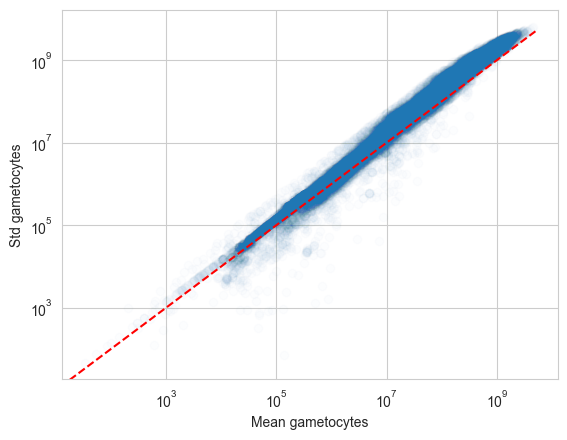

In [5]:
plt.scatter(foo["Gametocytes"]["mean"], foo["Gametocytes"]["std"], alpha=0.01)
# Plot identity line
plt.plot([0, 5e9], [0, 5e9], 'r--')
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Mean gametocytes")
plt.ylabel("Std gametocytes")

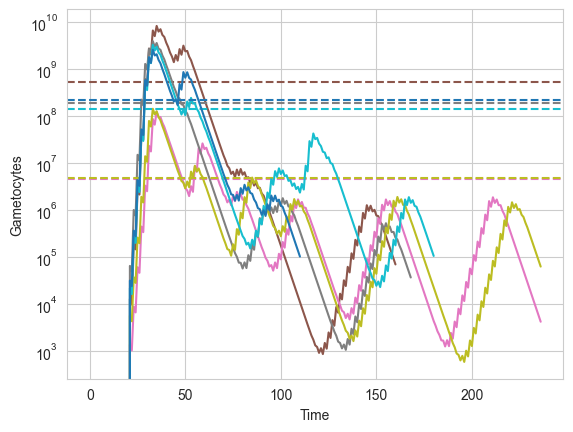

In [6]:
# Plot timeseries for first 10 infections
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"], c=color)
    plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    plt.yscale("log")

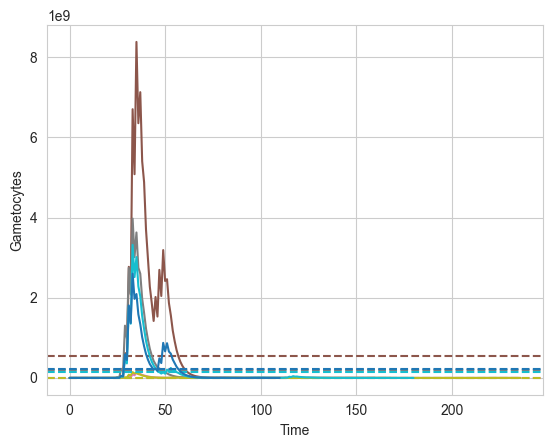

In [7]:
# Plot timeseries for first 10 infections
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"], c=color)
    plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    # plt.yscale("log")

meta NOT subset; don't know how to subset; dropped


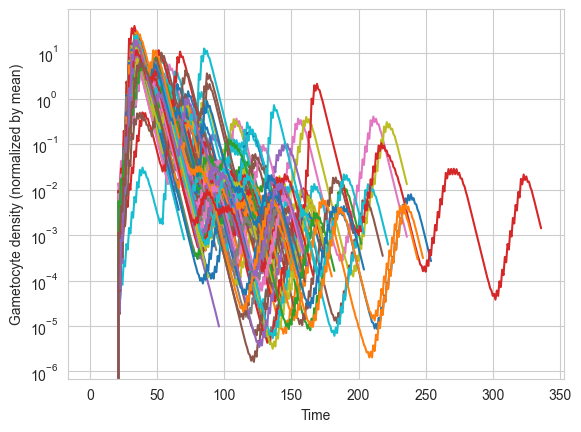

In [8]:
# Plot timeseries for first 10 infections, normalized by mean infectiousness
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 100 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"]/np.mean(group["Gametocytes"]), c=color)
    # plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    counter += 1
plt.xlabel("Time")
plt.ylabel("Gametocyte density (normalized by mean)")

plt.yscale("log")
    
plt.savefig("emod_gametocyte_timeseries_sample.pdf")

In [9]:
df.columns

Index(['Time', 'NodeID', 'IndividualID', 'Gender', 'AgeYears', 'InfectionID',
       'Infectiousness', 'Duration', 'Hepatocytes', 'IRBCs', 'Gametocytes'],
      dtype='object')

In [10]:

for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
    
    # Find height of first local maximum in gametocytes for each infection
    
        
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Gametocytes"]/np.mean(group["Gametocytes"]), c=color)
    # plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    plt.yscale("log")

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000001B55B563F70> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x000001B502FD10D0> (for post_execute):


KeyboardInterrupt: 

In [11]:
list(sorted(set(df["Time"])))[:10]

[18250, 18251, 18252, 18253, 18254, 18255, 18256, 18257, 18258, 18259]

In [12]:
# Count number of unique InfectionIDs
len(set(df["InfectionID"]))

74382

In [15]:
# Midcourse infection IDs have minimum time of 18250
midcourse_infection_ids = list(set(df[df["Time"] == 18250]["InfectionID"]))

# Filter out midcourse infections
df = df[~df["InfectionID"].isin(midcourse_infection_ids)]

In [14]:
len(midcourse_infection_ids)

2744

In [24]:
from scipy.stats import linregress
def get_slope_with_logtransform(x,y):
    slope, intercept, r_value, p_value, std_err = linregress(x, np.log(y))
    y_fitted = np.exp(intercept + slope*x)
    return slope, intercept, y_fitted

ValueError: Inputs must not be empty.

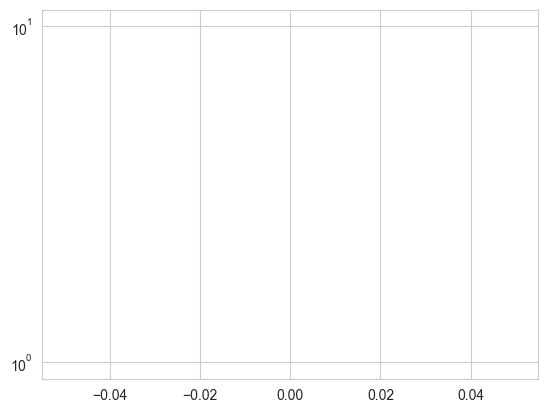

In [25]:
group["Time_Infection"] = group["Time"] - np.min(group["Time"])
group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()
plt.plot(group["Time_Infection"], group["Gametocytes_normalized"], c=color)
plt.yscale("log")

# Smooth Gametocytes on a rolling window with 2-day timescale
plt.plot(group["Time_Infection"], group["Gametocytes_normalized_smoothed"], c="k")

def find_first_local_maximum(time, height):
    # Compute the difference array
    diff = np.diff(height)
    
    # Find where the difference changes from positive to negative
    for i in range(1, len(diff)):
        if diff[i-1] > 0 and diff[i] <= 0:
            print(i)
            return time[i], height[i]
    
    return None, None

t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

# Fit a line to the timeseries after the first maximum
group_after_max = group[group["Time_Infection"] > t_first_max]

# Do linear regression between group_after_max["Time"] and group_after_max["Gametocytes_smoothed"]
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

slope, intercept, y_fitted = get_slope_with_logtransform(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

plt.axvline(x=t_first_max, c="r")
plt.axhline(y=h_first_max, c="r")

# Plot regression
# plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
plt.plot(group_after_max["Time_Infection"], np.exp(slope*group_after_max["Time_Infection"] + intercept), c="b")

In [ ]:
def fit_log_slope_under_constraint(time, height, constraint_time, constraint_height):
    log_height = np.log(height)
    log_constraint_height = np.log(constraint_height)
    
    def cost(m):
        # Constraint reduces problem to a single variable, using y=mx+b
        b = log_constraint_height - m*constraint_time
        
        # Compute cost as sum of squared differences
        log_height_pred = m*time + b
        return np.sum((log_height - log_height_pred)**2)
    
    from scipy.optimize import minimize
    res = minimize(cost, 0)
    
    m = res["x"][0]
    b = log_constraint_height - m*constraint_time
    
    return m,b

In [ ]:
m,b = fit_log_slope_under_constraint(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 
plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
plt.yscale("log")

plt.plot(group_after_max["Time_Infection"], np.exp(m*group_after_max["Time_Infection"]+b), c="r")

In [ ]:
group["Time_Infection"] = group["Time"] - np.min(group["Time"])
group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()
plt.plot(group["Time_Infection"], group["Gametocytes_normalized"], c=color)
plt.yscale("log")

# Smooth Gametocytes on a rolling window with 2-day timescale
plt.plot(group["Time_Infection"], group["Gametocytes_normalized_smoothed"], c="k")

def find_first_local_maximum(time, height):
    # Compute the difference array
    diff = np.diff(height)
    
    # Find where the difference changes from positive to negative
    for i in range(1, len(diff)):
        if diff[i-1] > 0 and diff[i] <= 0:
            print(i)
            return time[i], height[i]
    
    return None, None

t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

# Fit a line to the timeseries after the first maximum
group_after_max = group[group["Time_Infection"] > t_first_max]

# Do linear regression between group_after_max["Time"] and group_after_max["Gametocytes_smoothed"]
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

plt.axvline(x=t_first_max, c="r")
plt.axhline(y=h_first_max, c="r")

m,b = fit_log_slope_under_constraint(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 
# plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
# plt.yscale("log")

plt.plot(group_after_max["Time_Infection"], np.exp(m*group_after_max["Time_Infection"]+b), c="r", linestyle="--")

In [ ]:
counter = 0
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) != 18250:
        counter += 1
        if counter == 18:
            break

group["Time_Infection"] = group["Time"] - np.min(group["Time"])
group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()
plt.plot(group["Time_Infection"], group["Gametocytes_normalized"], c=color)
plt.yscale("log")

# Smooth Gametocytes on a rolling window with 2-day timescale
plt.plot(group["Time_Infection"], group["Gametocytes_normalized_smoothed"], c="k")

def find_first_local_maximum(time, height):
    # Compute the difference array
    diff = np.diff(height)
    
    # Find where the difference changes from positive to negative
    for i in range(1, len(diff)):
        if diff[i-1] > 0 and diff[i] <= 0:
            return time[i], height[i]
    
    return None, None

t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

# Fit a line to the timeseries after the first maximum, but before the first crossing with 1e-3
group_after_max = group[group["Time_Infection"] > t_first_max]

t_crossing = None
for i in range(1, len(group_after_max)):
    if group_after_max["Gametocytes_normalized"].values[i] < 1e-3:
        t_crossing = group_after_max["Time_Infection"].values[i]
        break

if t_crossing is None:
    group_of_interest = group_after_max
else:
    group_of_interest = group_after_max[group_after_max["Time_Infection"] < t_crossing]


# Do linear regression between group_after_max["Time"] and group_after_max["Gametocytes_smoothed"]
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"])

plt.axvline(x=t_first_max, c="r")
plt.axhline(y=h_first_max, c="r")

m,b = fit_log_slope_under_constraint(group_of_interest["Time_Infection"], group_of_interest["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 
# plt.plot(group_after_max["Time_Infection"], group_after_max["Gametocytes_normalized_smoothed"], c="b")
# plt.yscale("log")

plt.plot(group_of_interest["Time_Infection"], np.exp(m*group_of_interest["Time_Infection"]+b), c="r", linestyle="--")

print(t_first_max)
print(h_first_max)
print(m)

# Calculate total at max and 10 days later
t_window = np.logical_and(group["Time_Infection"] > t_first_max-2, group["Time_Infection"] < t_first_max + 8)
total_near_max = np.sum(group["Gametocytes_normalized"][t_window])
print(total_near_max/np.sum(group["Gametocytes_normalized"]))

# How bad is it to ignore the tail?
if t_crossing is not None:
    print(np.sum(group["Gametocytes_normalized"][group["Time_Infection"] > t_crossing])/np.sum(group["Gametocytes_normalized"]))

plt.ylabel("Gametocytes (normalized by mean)")
plt.xlabel("Days since infection start")

In [ ]:
# Get these metrics for all infections
t_first_max_list = []
h_first_max_list = []
m_list = []
age_list = []
infection_duration = []
mean_gametocyte_level = []

for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) != 18250:
        group["Time_Infection"] = group["Time"] - np.min(group["Time"])
        group["Gametocytes_normalized"] = group["Gametocytes"]/np.mean(group["Gametocytes"])
        group["Gametocytes_normalized_smoothed"] = group["Gametocytes_normalized"].rolling(window=2).mean()

        t_first_max, h_first_max = find_first_local_maximum(group["Time_Infection"].values, group["Gametocytes_normalized_smoothed"].values)

        if t_first_max is None or h_first_max is None:
            continue

        # Fit a line to the timeseries after the first maximum, but before the first crossing with 1e-3
        group_after_max = group[group["Time_Infection"] > t_first_max]

        t_crossing = None
        for i in range(1, len(group_after_max)):
            if group_after_max["Gametocytes_normalized"].values[i] < 1e-3:
                t_crossing = group_after_max["Time_Infection"].values[i]
                break

        if t_crossing is None:
            group_of_interest = group_after_max
        else:
            group_of_interest = group_after_max[group_after_max["Time_Infection"] < t_crossing]

        m,b = fit_log_slope_under_constraint(group_of_interest["Time_Infection"], group_of_interest["Gametocytes_normalized_smoothed"], t_first_max, h_first_max) 

        age_list.append(np.mean(group["AgeYears"]))
        t_first_max_list.append(t_first_max)
        h_first_max_list.append(h_first_max)
        m_list.append(m)
        infection_duration.append(np.max(group["Time_Infection"]))
        mean_gametocyte_level.append(np.mean(group["Gametocytes"]))

In [ ]:
age_list = np.array(age_list)
t_first_max_list = np.array(t_first_max_list)
h_first_max_list = np.array(h_first_max_list)
m_list = np.array(m_list)

# Cap age at 80
age_list = np.minimum(age_list, 80)

In [ ]:
plt.hist(t_first_max_list, bins=20)

In [ ]:
plt.hist(h_first_max_list, bins=20)

In [ ]:
plt.hist(m_list, bins=20)

In [ ]:
plt.scatter(np.log10(mean_gametocyte_level), m_list, alpha=0.1)

In [ ]:
plt.scatter(infection_duration, np.log10(mean_gametocyte_level), c=m_list, alpha=0.1)
plt.colorbar()

In [ ]:
plt.scatter(age_list, m_list, alpha=0.1)

In [ ]:
plt.scatter(h_first_max_list, m_list, alpha=0.1, c=age_list)
plt.colorbar()

In [ ]:
plt.scatter(infection_duration, m_list, alpha=0.1, c=age_list)

In [ ]:
plt.scatter(infection_duration, h_first_max_list, alpha=0.1, c=age_list)

In [ ]:
find_first_local_maximum(group["Time"].values, group["Gametocytes_smoothed"].values)

In [ ]:
def plot_model_fit(t_first_max, duration, m, y_floor=1e-4):
    # Gametocytes show up after 21 days and rise rapidly to first peak
    t_start = 21
    h_start = 1e-4
    
    h_first_max = duration/10
    
    # y = np.exp(mx+b)
    m_rise = (np.log(h_first_max) - np.log(h_start)) / (t_first_max - t_start)
    b = np.log(h_start) - m_rise*t_start
    y = np.exp(m_rise*np.arange(t_start, t_first_max) + b)
    
    # Gametocytes rapidly decay after first peak
    b = np.log(h_first_max) - m*t_first_max
    y2 = np.exp(m*np.arange(t_first_max, duration) + b)
    y2 = np.maximum(y2, y_floor)
    
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.scatter(np.arange(t_start, t_first_max), y, c="r")
    plt.scatter(t_first_max, h_first_max, c="r")
    plt.scatter(np.arange(t_first_max, duration), y2, c="r")
    plt.yscale("log")
    plt.xlim([0,duration])
    plt.xlabel("Days since infection start")
    plt.ylabel("Gametocytes (normalized by mean)")
    
    y_full = np.concatenate([y, y2])
    y_full = np.maximum(y_full, y_floor)
    
    plt.subplot(1,2,2)
    plt.plot(np.cumsum(np.sort(y_full)[::-1])/np.sum(y_full))
    plt.axhline(y=0.9, c="r")
    plt.xlabel("Number of days")
    plt.ylabel("Fraction of total gametocytes")
    
    plt.tight_layout()
    plt.show()
    
    

    
    return y_full
    
    

y = plot_model_fit(t_first_max=35, duration=200, m=-0.1)


In [ ]:
from functools import partial
import math

def expcdf(x, lmbda=1):
    if x < 0:
        return 0
    else:
        return 1 - math.exp(-lmbda * x)
    
def get_inv_micro_liters_blood(age_years):
    age_effective = min(age_years, 20)
    return 1e-6/(0.225*age_effective + 0.5)

base_gametocyte_mosquito_survival = 0.002011099

def infectiousness_from_gametocytes(n_gametocytes, age_years):
    inv_microliters_blood = get_inv_micro_liters_blood(age_years)
    microliters_per_bloodmeal = 1    
    fever_effect = 0
    return expcdf(n_gametocytes * inv_microliters_blood * microliters_per_bloodmeal * base_gametocyte_mosquito_survival * (1.0 - fever_effect))

# infectiousness_from_gametocytes = np.vectorize(partial(infectiousness_from_gametocytes, age_years=10))

In [ ]:
foo = partial(infectiousness_from_gametocytes, age_years=10)
bar = np.vectorize(foo)

In [ ]:
duration = 200
mean_g = 10**8
y = plot_model_fit(t_first_max=35, duration=duration, m=-0.05)

print("Mean y = ",np.mean(y))

g = y*mean_g

i = bar(g)
# plt.axhline(np.mean(i), c="k", linestyle='--')
plt.plot(np.arange(21, duration), i)
# plt.axhline(bar(mean_g), linestyle='dotted', c="C1")
plt.xlim([0,duration])
plt.xlabel("Days since infection start")
plt.ylabel("Infectiousness")

# print(bar(mean_g))

In [ ]:
# Let's take 3 cotransmitted strains
duration = 200
mean_g = 10**8/3

y1 = plot_model_fit(t_first_max=34, duration=duration, m=-0.1)
y2 = plot_model_fit(t_first_max=36, duration=duration, m=-0.2)
y3 = plot_model_fit(t_first_max=34, duration=duration, m=-0.15)

# print("Mean y = ",np.mean(y))

g1 = y1*mean_g
g2 = y2*mean_g
g3 = y3*mean_g

i1 = bar(g1)
i2 = bar(g2)
i3 = bar(g3)
i_total = 1-(1-i1)*(1-i2)*(1-i3)

plt.figure()
plt.plot(np.arange(21, duration), i1)
plt.plot(np.arange(21, duration), i2)
plt.plot(np.arange(21, duration), i3)
# plt.plot(np.arange(21, duration), i_total, c="k", lw=2)
plt.xlabel("Time")
plt.ylabel("Infectiousness by strain")
plt.show()

plt.figure()
g_total = g1 + g2 + g3
prob_clonal = (g1/g_total)**2 + (g2/g_total)**2 + (g3/g_total)**2
prob_clonal_transmission_weighted = np.sum(i_total*prob_clonal)/np.sum(i_total)
plt.plot(np.arange(21, duration), prob_clonal)
plt.axhline(1/3, c="purple", linestyle='dashed', label="Prob_clonal if constant infectiousness")
plt.axhline(prob_clonal_transmission_weighted, c="k", linestyle='dashed', label="Prob_clonal - transmission-weighted")
plt.ylim([0,1])
plt.legend()
plt.xlabel("Time")
plt.ylabel("Probability that oocyst is clone of a parent strain")



# plt.axhline(bar(mean_g), linestyle='dotted', c="C1")
# plt.xlim([0,duration])
# plt.xlabel("Days since infection start")
# plt.ylabel("Infectiousness")
# 
# # print(bar(mean_g))

In [ ]:
# Let's take 3 superinfected strains
duration = 200
mean_g = 10**8/3

y1 = plot_model_fit(t_first_max=34, duration=duration, m=-0.1)
y2 = plot_model_fit(t_first_max=36, duration=duration, m=-0.2)
y3 = plot_model_fit(t_first_max=34, duration=duration, m=-0.15)

t_offset_2 = 30
t_offset_3 = 40
# print("Mean y = ",np.mean(y))

g1 = y1*mean_g
g2 = y2*mean_g
g3 = y3*mean_g

i1 = bar(g1)
i2 = bar(g2)
i3 = bar(g3)
i_total = 1-(1-i1)*(1-i2)*(1-i3)

plt.figure()
plt.plot(np.arange(21, duration), i1)
plt.plot(np.arange(21 + t_offset_2, duration + t_offset_2), i2)
plt.plot(np.arange(21 + t_offset_3, duration + t_offset_3), i3)
# plt.plot(np.arange(21, duration), i_total, c="k", lw=2)
plt.xlabel("Time")
plt.ylabel("Infectiousness by strain")
plt.show()

df = pd.DataFrame({"t": np.array([0,300])})


# 
# plt.figure()
# g_total = g1 + g2 + g3
# prob_clonal = (g1/g_total)**2 + (g2/g_total)**2 + (g3/g_total)**2
# prob_clonal_transmission_weighted = np.sum(i_total*prob_clonal)/np.sum(i_total)
# plt.plot(np.arange(21, duration), prob_clonal)
# plt.axhline(1/3, c="purple", linestyle='dashed', label="Prob_clonal if constant infectiousness")
# plt.axhline(prob_clonal_transmission_weighted, c="k", linestyle='dashed', label="Prob_clonal - transmission-weighted")
# plt.ylim([0,1])
# plt.xlabel("Time")
# plt.ylabel("Probability that oocyst is clone of a parent strain")
# 


# plt.axhline(bar(mean_g), linestyle='dotted', c="C1")
# plt.xlim([0,duration])
# plt.xlabel("Days since infection start")
# plt.ylabel("Infectiousness")
# 
# # print(bar(mean_g))

In [ ]:
np.sum(y1)/duration

In [ ]:
np.sum(y2)/duration

In [ ]:
np.sum(y3)/duration

In [ ]:
np.sum(i1)/duration

In [ ]:
plt.subplot(1,2,2)
plt.plot(np.cumsum(np.sort(y)[::-1])/np.sum(y))
plt.axhline(y=0.9, c="r")
plt.xlabel("Number of days")
plt.ylabel("Fraction of total gametocytes")

In [ ]:
plt.plot(np.cumsum(np.sort(y)[::-1])/np.sum(y))
plt.axhline(y=0.9, c="r")
plt.xlabel("Number of days")
plt.ylabel("Fraction of total gametocytes")

In [ ]:
# Plot timeseries for first 10 infections
start_counter = 55
counter = 1
for i, group in df.groupby("InfectionID"):
    # Make sure we aren't looking at mid-course infections
    if np.min(group["Time"]) == 18250:
        continue
        
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"]-np.min(group["Time"]), group["Infectiousness"], c=color)
    plt.axhline(y=np.mean(group["Infectiousness"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Infectiousness")
    counter += 1
    
    plt.yscale("log")

In [ ]:
# Plot timeseries for first 10 infections
counter = 1
for i, group in df.groupby("InfectionID"):
    if counter > 10:
        break
    plt.plot(group["Time"], group["Infectiousness"], c=f"C{counter}")
    # plt.
    counter += 1

Try to write a sawtooth function which mimics this type of behavior:
1. mean =1 
2. period of 55
3. whose peak is 3 orders of magnitude higher than the trough

In [ ]:
f = np.zeros(55)

In [ ]:
f[0] = 1e-3
f[27] = 1
f[54] = 1e-3

print(f)

In [ ]:
g = np.exp(np.log(1e3)/27)
print(g)

In [ ]:
for i in range(1, 27):
    print(i)
    f[i] = f[i-1] * g
print(f)
for i in range(28, 54):
    f[i] = f[i-1] / g
print(f)

In [ ]:
plt.plot(f)
plt.axhline(y=np.mean(f), c="r", linestyle="--")
plt.yscale("log")

In [ ]:
# Rescale f to have mean 1
f = f / np.mean(f)

In [ ]:
np.mean(f)

In [ ]:
plt.plot(f)
plt.axhline(y=np.mean(f), c="r", linestyle="--")
plt.yscale("log")

In [ ]:
# Plot timeseries for first 10 infections
start_counter = 15
counter = 1
for i, group in df.groupby("InfectionID"):
    if counter < start_counter:
        counter += 1
        continue
        
    if counter > 5 + start_counter:
        break
    color = f"C{counter}"
    plt.plot(group["Time"], group["Gametocytes"], c=color)
    plt.axhline(y=np.mean(group["Gametocytes"]), c=color, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Gametocytes")
    counter += 1
    
    plt.yscale("log")
    
# Add plot of f
start_time = 18280
plt.plot(start_time + np.arange(len(f)), f*1e6, c="k")

In [ ]:
np.mean(f[10:35])

In [ ]:
f.to_csv("sawtooth.csv", index=False)

In [ ]:
df_sawtooth = pd.DataFrame({"t": np.arange(55), "f": f})

In [ ]:
df_sawtooth.to_csv("sawtooth.csv", index=False)

# EMOD infectiousness

In [ ]:
g = f*1e8
plt.plot(g)

In [ ]:
import math

def expcdf(x, lmbda=1):
    if x < 0:
        return 0
    else:
        return 1 - math.exp(-lmbda * x)
    
def get_inv_micro_liters_blood(age_years):
    age_effective = min(age_years, 20)
    return 1e-6/(0.225*age_effective + 0.5)

base_gametocyte_mosquito_survival = 0.002011099

def infectiousness_from_gametocytes(n_gametocytes, age_years):
    inv_microliters_blood = get_inv_micro_liters_blood(age_years)
    microliters_per_bloodmeal = 1    
    fever_effect = 0
    return expcdf(n_gametocytes * inv_microliters_blood * microliters_per_bloodmeal * base_gametocyte_mosquito_survival * (1.0 - fever_effect))


In [ ]:
infectiousness_from_gametocytes(1e8, 10)

In [ ]:
x = np.vectorize(infectiousness_from_gametocytes)

In [ ]:
plt.plot(x(g,10))

In [ ]:
np.mean(x(g,10))

In [ ]:
# Plot all infections from individual people

for i, group in df.groupby("IndividualID"):
    # Only plot if the person has more than 1 infection
    if len(group) > 1:
        # Plot each infection individually
        for j, group2 in group.groupby("InfectionID"):
            plt.plot(group2["Time"], group2["Gametocytes"])
        plt.yscale("log")
        break

In [ ]:
y1 = plot_model_fit(t_first_max=34, duration=300, m=-0.05)

In [ ]:
np.mean(y1)

In [ ]:
y1 = plot_model_fit(t_first_max=34, duration=300, m=-0.15)

In [ ]:
np.mean(y1)

In [ ]:
y1 = plot_model_fit(t_first_max=34, duration=300, m=-0.1)

In [ ]:
y1 = plot_model_fit(t_first_max=34, duration=200, m=-0.1)

In [ ]:
y1 = plot_model_fit(t_first_max=34, duration=80, m=-0.25)

# Try to define a single generic shape we can use for all infections

In [37]:
def fake_shape_1(duration, y_floor=1e-4):
    # Gametocytes show up after 21 days and rise rapidly to first peak, which is an integer uniformly drawn from [34,36]
    t_start = 21
    h_start = 1e-4
    
    t_first_max = np.random.randint(34,37)
    # h_first_max = 15 # times the mean
    h_first_max = np.random.uniform(10, 20)
    
    # y = np.exp(mx+b)
    m_rise = (np.log(h_first_max) - np.log(h_start)) / (t_first_max - t_start)
    b_rise = np.log(h_start) - m_rise*t_start
    y_rise = np.exp(m_rise*np.arange(t_start, t_first_max) + b_rise)
    
    # Gametocytes rapidly decay after first peak.
    # Slope is uniformly drawn from [-0.15,-0.07], and then stays at floor of y_floor
    # However, for very short infections, take more steep slow to ensure that we end at y_floor
    m_decay_max = (np.log(y_floor) - np.log(h_first_max)) / (duration - t_first_max)
    
    if m_decay_max < -0.15:
        m_decay = m_decay_max
    elif m_decay_max > -0.07:
        m_decay = np.random.uniform(-0.15, -0.07)
    else:
        m_decay = np.random.uniform(-0.15, m_decay_max)
        
    b_decay = np.log(h_first_max) - m_decay*t_first_max
    y_decay = np.exp(m_decay*np.arange(t_first_max, duration) + b_decay)
    
    y_rise_and_decay = np.concatenate([y_rise, y_decay])
    # Rescale to have mean of 1
    y_rise_and_decay = y_rise_and_decay / np.mean(y_rise_and_decay)
    
    # Now impose floor (note that doing this after the rescaling will not guarantee that the mean is 1, but it's close enough)
    y_rise_and_decay = np.maximum(y_rise_and_decay, y_floor)
    
    y_full = np.concatenate([np.zeros(t_start), y_rise_and_decay])
    
    return y_full

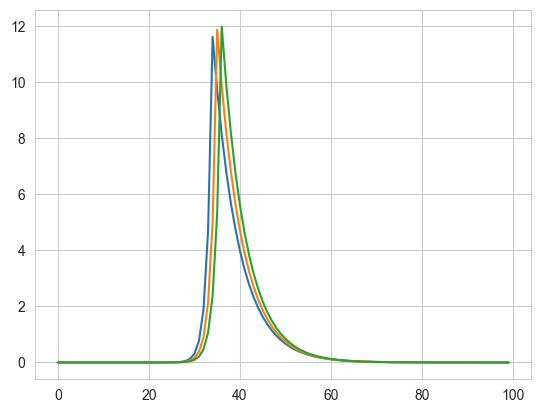

In [38]:
plt.plot(fake_shape_1(100))
plt.plot(fake_shape_1(100))
plt.plot(fake_shape_1(100))

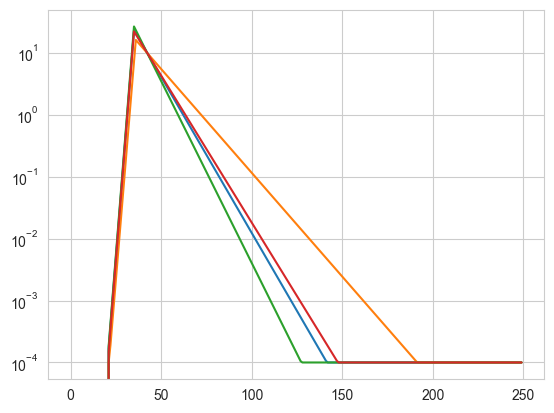

In [39]:
plt.plot(fake_shape_1(250))
plt.plot(fake_shape_1(250))
plt.plot(fake_shape_1(250))
plt.plot(fake_shape_1(250))
plt.yscale("log")

In [40]:
a = fake_shape_1(200)
np.mean(a[a>0])

1.0000372268867725

1.0000166207910468
1.0000109729047364
1.0000415263734093
1.0000005207344138


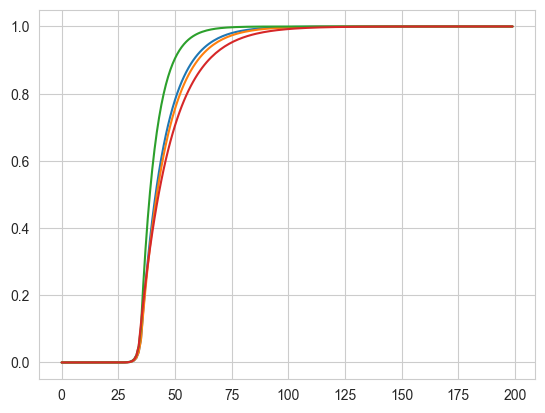

In [41]:
for i in range(4):
    a = fake_shape_1(200)
    plt.plot(np.cumsum(a)/np.sum(a))
    print(np.mean(a[a>0]))
# plt.yscale("log")

In [48]:
def current_gametocyte_density(infection_age, infection_duration, aggregate_gametocyte_density, t_first_max, h_first_max, m_decay, y_floor=1e-4):
    # Return gametocyte density at a given time point in the infection
    if infection_age <= 21:
        return 0

    # Gametocytes show up after 21 days and rise rapidly to first peak
    t_start = 21
    h_start = 1e-4

    m_rise = (np.log(h_first_max) - np.log(h_start)) / (t_first_max - t_start)
    b_rise = np.log(h_start) - m_rise * t_start
    y_rise = np.exp(m_rise * np.arange(t_start, t_first_max) + b_rise)

    # Gametocytes rapidly decay after first peak.
    b_decay = np.log(h_first_max) - m_decay * t_first_max
    y_decay = np.exp(m_decay * np.arange(t_first_max, infection_duration) + b_decay)

    y_rise_and_decay = np.concatenate([y_rise, y_decay])
    # Rescale to have mean of 1
    y_rise_and_decay = y_rise_and_decay / np.sum(y_rise_and_decay)

    # Now impose floor (note that doing this after the rescaling will not guarantee that the mean is 1, but it's close enough)
    y_rise_and_decay = np.maximum(y_rise_and_decay, y_floor)

    return y_rise_and_decay[infection_age - 21] * aggregate_gametocyte_density

In [49]:
def infectiousness_from_gametocyte_density(gametocyte_density):
    # EMOD function which relates gametocyte density to infectiousness
    base_gametocyte_mosquito_survival = 0.002011099
    return 1 - np.exp(-base_gametocyte_mosquito_survival * gametocyte_density)

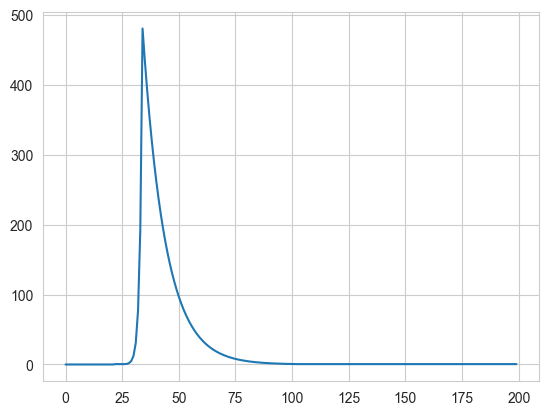

In [50]:
x = np.arange(200).astype(float)
xx = np.arange(200).astype(float)
for t in range(1,200):
    x[t] = current_gametocyte_density(t, 200, 30*179, 34, 15, -0.1)
    xx[t] = infectiousness_from_gametocyte_density(x[t])
    
plt.plot(x)

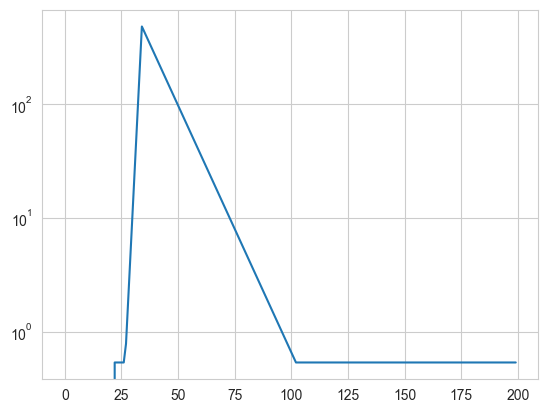

In [51]:
plt.plot(x)
plt.yscale("log")

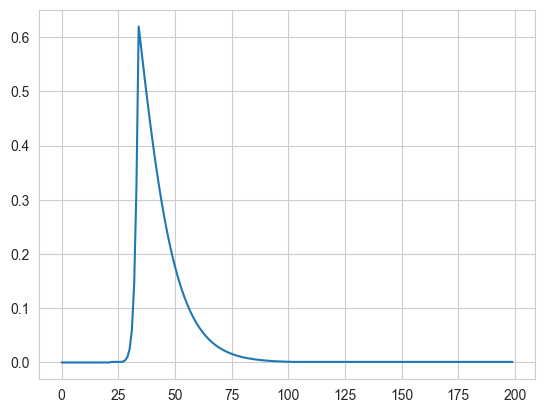

In [52]:
plt.plot(xx)

In [31]:
np.mean(xx)

0.04364214052223114

In [32]:
np.mean(xx[xx>0])

0.04903611294632712

In [33]:
xx[190]

0.0010793772158952386

In [34]:
np.max(xx)

0.6195713757867076

In [35]:
np.max(x)

480.5614758263283

In [36]:
np.min(x[x>0])

0.537

In [37]:
current_gametocyte_density(50, 200, 1e8, 34, 15, -0.1)

1806772.600590475

In [38]:
np.mean(x[x>0])

30.444755057988704

In [39]:
infectiousness_from_gametocyte_density(np.mean(x[x>0]))

0.05939069458046542

In [40]:
np.sum(x)

5419.166400321989

In [41]:
30*179

5370

In [53]:
def draw_gametocyte_shape_parameters(infection_durations, y_floor=1e-4):

    N_infections = len(infection_durations)

    t_first_max = np.random.randint(34, 37, size=N_infections)
    h_first_max = np.random.uniform(10, 20, size=N_infections)

    # m_decay = np.random.uniform(-0.15, -0.07, size=N_infections)

    # Gametocytes rapidly decay after first peak.
    # Slope is uniformly drawn from [-0.15,-0.07], and then stays at floor of y_floor
    # However, for very short infections, take more steep slow to ensure that we end at y_floor
    m_decay = np.empty(N_infections)
    for i in range(N_infections):
        m_decay_max = (np.log(y_floor) - np.log(h_first_max[i])) / (infection_durations[i] - t_first_max[i])

        if m_decay_max < -0.15:
            m_decay[i] = m_decay_max
        elif m_decay_max > -0.07:
            m_decay[i] = np.random.uniform(-0.15, -0.07)
        else:
            m_decay[i] = np.random.uniform(-0.15, m_decay_max)

    return t_first_max, h_first_max, m_decay

In [54]:
draw_gametocyte_shape_parameters([80,100,100,100,200,200,200])

(array([35, 36, 34, 34, 35, 35, 34]),
 array([15.2180776 , 10.97104873, 10.92603759, 17.35783724, 14.70261743,
        14.10199037, 10.99185965]),
 array([-0.26517388, -0.1813375 , -0.17578014, -0.1827937 , -0.14027221,
        -0.13853363, -0.14265282]))

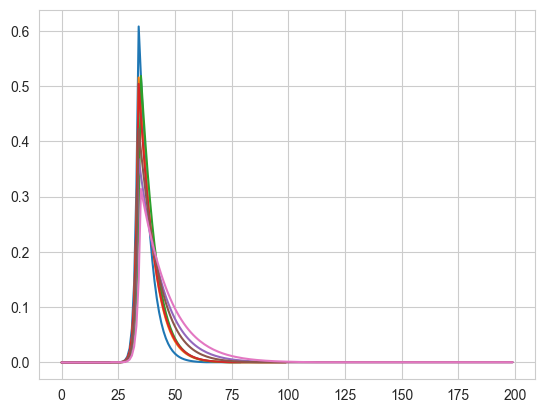

In [56]:
durations = [80,100,100,100,200,200,200]
tfm,hfm,md = draw_gametocyte_shape_parameters(durations)
for t_first_max, h_first_max, m_decay, duration in zip(tfm,hfm,md,durations):
    x = np.arange(duration).astype(float)
    xx = np.arange(duration).astype(float)
    for t in range(duration):
        x[t] = current_gametocyte_density(t, duration, 30*80, t_first_max=t_first_max, h_first_max=h_first_max, m_decay=m_decay)
        xx[t] = infectiousness_from_gametocyte_density(x[t])
    # plt.plot(x)
    # print(np.sum(x))
    plt.plot(xx)
# plt.yscale("log")

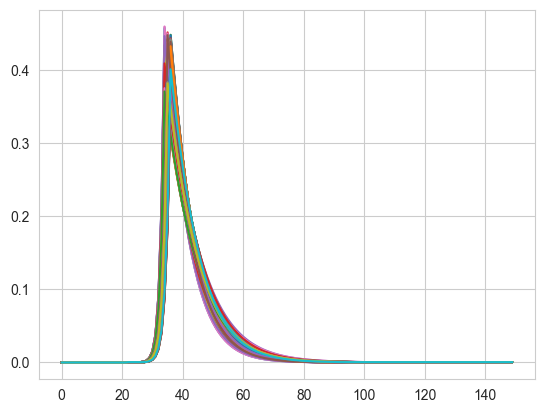

In [46]:
durations = [150]*100
tfm,hfm,md = draw_gametocyte_shape_parameters(durations)
for t_first_max, h_first_max, m_decay, duration in zip(tfm,hfm,md,durations):
    x = np.arange(duration).astype(float)
    xx = np.arange(duration).astype(float)
    for t in range(duration):
        x[t] = current_gametocyte_density(t, duration, 30*80, t_first_max=t_first_max, h_first_max=h_first_max, m_decay=m_decay)
        xx[t] = infectiousness_from_gametocyte_density(x[t])
    # plt.plot(x)
    # print(np.sum(x))
    plt.plot(xx)
# plt.yscale("log")

# Check from data how long to 90% of gametocytes produced

For each InfectionID, calculate the time between the start of the infection and the time when cumsum of Gametocytes is 90% of the total

In [25]:
def time_to_90_percent_gametocytes(group):
    total_gametocytes = np.sum(group["Gametocytes"])
    cumsum_gametocytes = np.cumsum(group["Gametocytes"])
    end_time = group["Time"].values[np.argmax(cumsum_gametocytes > 0.9*total_gametocytes)]
    start_time = np.min(group["Time"])
    return end_time - start_time

def infection_duration(group):
    return np.max(group["Time"]) - np.min(group["Time"])

In [27]:
foo1 = df.groupby("InfectionID").apply(time_to_90_percent_gametocytes).reset_index().rename(columns={0: "TimeTo90PercentGametocytes"})
foo2 = df.groupby("InfectionID").apply(infection_duration).reset_index().rename(columns={0: "InfectionDuration"})

foo3 = pd.merge(foo1, foo2, on="InfectionID")

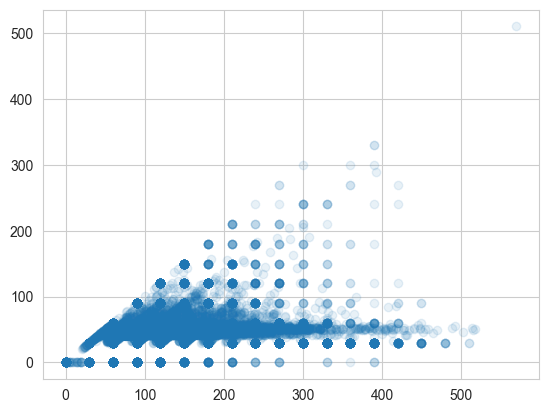

In [30]:
plt.scatter(foo3["InfectionDuration"], foo3["TimeTo90PercentGametocytes"], alpha=0.1)

In [81]:

weird = (foo3["InfectionDuration"]%30 == 0) | (foo3["TimeTo90PercentGametocytes"] %30 == 0)

In [82]:
np.sum(weird)

58441

In [83]:
np.sum(~weird)

13197

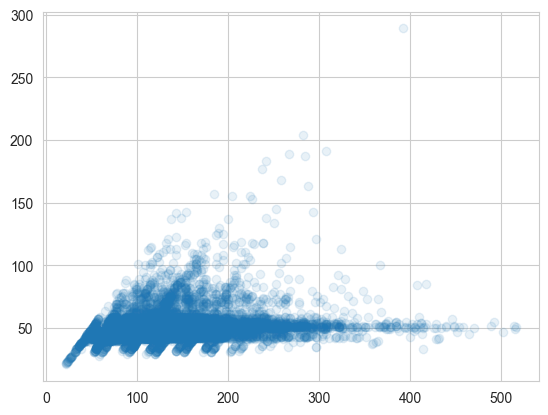

In [84]:
plt.scatter(foo3["InfectionDuration"][~weird], foo3["TimeTo90PercentGametocytes"][~weird], alpha=0.1)

(array([1.500e+01, 4.600e+01, 2.980e+02, 1.793e+03, 2.900e+03, 5.398e+03,
        1.508e+03, 4.000e+02, 2.110e+02, 1.860e+02, 1.500e+02, 1.040e+02,
        4.200e+01, 4.000e+01, 2.300e+01, 1.700e+01, 1.500e+01, 1.400e+01,
        1.000e+01, 4.000e+00, 1.000e+00, 5.000e+00, 3.000e+00, 1.000e+00,
        1.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 21.  ,  26.36,  31.72,  37.08,  42.44,  47.8 ,  53.16,  58.52,
         63.88,  69.24,  74.6 ,  79.96,  85.32,  90.68,  96.04, 101.4 ,
        106.76, 112.12, 117.48, 122.84, 128.2 , 133.56, 138.92, 144.28,
        149.64, 155.  , 160.36, 165.72, 171.08, 176.44, 181.8 , 187.16,
        192.52, 197.88, 203.24, 208.6 , 213.96, 219.32, 224.68, 230.04,
        235.4 , 

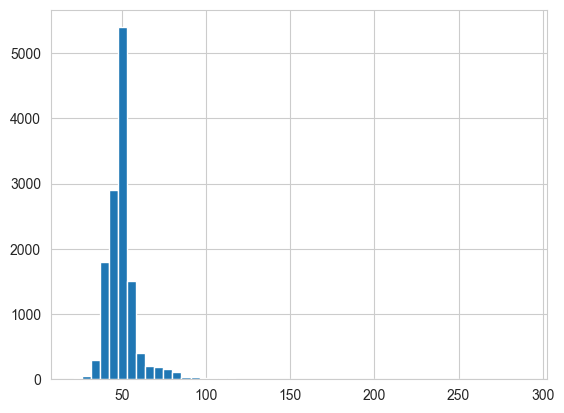

In [85]:
plt.hist(foo3["TimeTo90PercentGametocytes"][~weird], bins=50)

In [58]:
durations

0         56
1        164
2         72
4         72
5        108
        ... 
14168    171
14169    411
14170     81
14171     51
14172    141
Name: InfectionDuration, Length: 13329, dtype: int64

In [70]:
# What does the distribution look like for our fake_shapes
durations = foo3["InfectionDuration"][~weird].values
tfm,hfm,md = draw_gametocyte_shape_parameters(durations)
t90 = np.zeros(len(durations))

i = 0
for t_first_max, h_first_max, m_decay, duration in zip(tfm,hfm,md,durations):
    x = np.arange(duration).astype(float)
    xx = np.arange(duration).astype(float)
    for t in range(duration):
        x[t] = current_gametocyte_density(t, duration, 30*80, t_first_max=t_first_max, h_first_max=h_first_max, m_decay=m_decay)
        # xx[t] = infectiousness_from_gametocyte_density(x[t])
        
    if np.sum(x) == 0:
        t90[i] = np.nan
    else:
        g_cumsum = np.cumsum(x)/np.sum(x)
        # find time that g_cumsum first crosses 0.9
        t90[i] = np.min(np.where(g_cumsum > 0.9))
    i += 1
    # plt.plot(x)
    # print(np.sum(x))
    # plt.plot(xx)
# plt.yscale("log")

C:\Users\joshsu\AppData\Local\Temp\ipykernel_11132\4005280742.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  m_decay_max = (np.log(y_floor) - np.log(h_first_max[i])) / (infection_durations[i] - t_first_max[i])


In [71]:
t90

array([37., 52., 40., ..., 44., 38., 51.])

48.96044815399654
50.54722784905094


Text(0.5, 1.0, 'Comparison of observed and synthetic gametocyte trajectories for same infection durations')

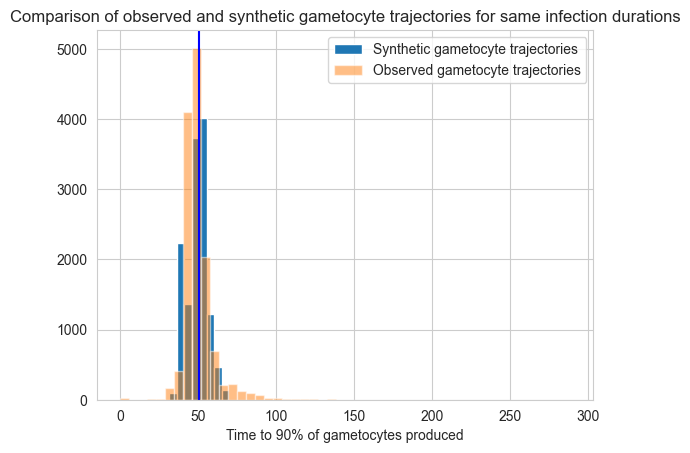

In [77]:
plt.hist(t90, label="Synthetic gametocyte trajectories")
plt.hist(foo3["TimeTo90PercentGametocytes"][~weird].values, bins=50, alpha=0.5, label="Observed gametocyte trajectories")
plt.xlabel("Time to 90% of gametocytes produced")
plt.legend()

plt.axvline(np.mean(t90), c="r")
plt.axvline(np.mean(foo3["TimeTo90PercentGametocytes"][~weird].values), c="b")
print(np.nanmean(t90))
print(np.mean(foo3["TimeTo90PercentGametocytes"][~weird].values))

plt.title("Comparison of observed and synthetic gametocyte trajectories for same infection durations")

Here we have three options. 

Option one: keep as-is. the current trajectories that have a range- this is more realistic but requires a bit more computation to evolve forward under the current scheme (for each row in infection_lookup, use associated parameters to compute gametocytes at current time)

Option two: Simplify the gametocyte shape. We can use a single functional form for all infections. This is less realistic but faster/simpler to implement - can use a single array as a lookup table for gametocyte density at each time point

Option three: keep as-is but pre-compute things so 



# Even simpler gametocyte shape. Single functional form


In [88]:
def draw_simplified_gametocyte_shape_parameters(infection_durations, y_floor=1e-4):

    N_infections = len(infection_durations)

    t_first_max = 35.5 #np.mean([34,37]) #np.random.randint(34, 37, size=N_infections)
    h_first_max = 15 #np.random.uniform(10, 20, size=N_infections)

    # m_decay = np.random.uniform(-0.15, -0.07, size=N_infections)

    # Gametocytes rapidly decay after first peak.
    # Slope is uniformly drawn from [-0.15,-0.07], and then stays at floor of y_floor
    # However, for very short infections, take more steep slow to ensure that we end at y_floor
    # m_decay = np.empty(N_infections)
    # for i in range(N_infections):
    #     m_decay_max = (np.log(y_floor) - np.log(h_first_max[i])) / (infection_durations[i] - t_first_max[i])
    # 
    #     if m_decay_max < -0.15:
    #         m_decay[i] = m_decay_max
    #     elif m_decay_max > -0.07:
    #         m_decay[i] = np.random.uniform(-0.15, -0.07)
    #     else:
    #         m_decay[i] = np.random.uniform(-0.15, m_decay_max)
    #         
    m_decay = -0.11

    return t_first_max, h_first_max, m_decay

In [89]:
# What does the distribution look like for our fake_shapes
durations = foo3["InfectionDuration"][~weird].values
# tfm,hfm,md = draw_gametocyte_shape_parameters(durations)
t90 = np.zeros(len(durations))

i = 0

tfm = 35.5
hfm = 15
md = -0.11

for duration in durations:
    x = np.arange(duration).astype(float)
    xx = np.arange(duration).astype(float)
    for t in range(duration):
        x[t] = current_gametocyte_density(t, duration, 30*80, t_first_max=t_first_max, h_first_max=h_first_max, m_decay=m_decay)
        # xx[t] = infectiousness_from_gametocyte_density(x[t])
        
    if np.sum(x) == 0:
        t90[i] = np.nan
    else:
        g_cumsum = np.cumsum(x)/np.sum(x)
        # find time that g_cumsum first crosses 0.9
        t90[i] = np.min(np.where(g_cumsum > 0.9))
    i += 1

C:\Users\joshsu\AppData\Local\Temp\ipykernel_11132\4005280742.py:15: RuntimeWarning: divide by zero encountered in scalar divide
  m_decay_max = (np.log(y_floor) - np.log(h_first_max[i])) / (infection_durations[i] - t_first_max[i])


50.31749279975747
50.55270137152383


Text(0.5, 1.0, 'Comparison of observed and synthetic gametocyte trajectories for same infection durations')

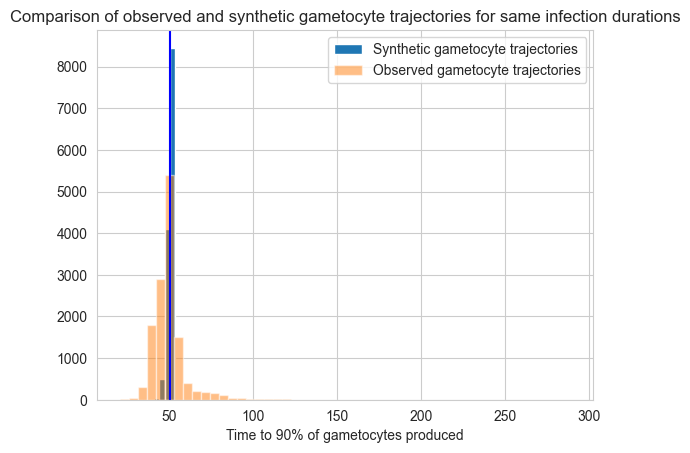

In [90]:
plt.hist(t90, label="Synthetic gametocyte trajectories")
plt.hist(foo3["TimeTo90PercentGametocytes"][~weird].values, bins=50, alpha=0.5, label="Observed gametocyte trajectories")
plt.xlabel("Time to 90% of gametocytes produced")
plt.legend()

plt.axvline(np.mean(t90), c="r")
plt.axvline(np.mean(foo3["TimeTo90PercentGametocytes"][~weird].values), c="b")
print(np.nanmean(t90))
print(np.mean(foo3["TimeTo90PercentGametocytes"][~weird].values))

plt.title("Comparison of observed and synthetic gametocyte trajectories for same infection durations")

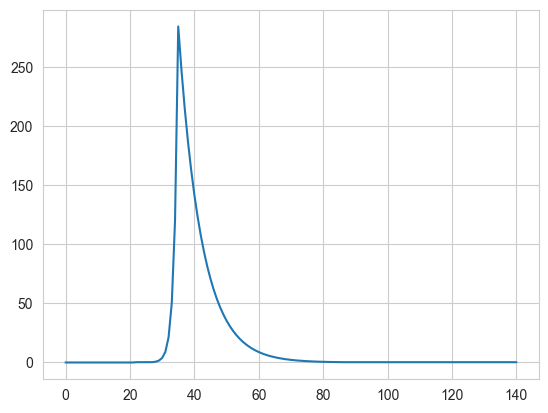

In [91]:
plt.plot(x)

In [92]:
np.log10(x)

C:\Users\joshsu\AppData\Local\Temp\ipykernel_11132\2432066342.py:1: RuntimeWarning: divide by zero encountered in log10
  np.log10(x)


array([       -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf,        -inf,        -inf,        -inf,
              -inf,        -inf, -0.61978876, -0.61978876, -0.61978876,
       -0.61978876, -0.61978876, -0.5456083 , -0.17067836,  0.20425159,
        0.57918153,  0.95411148,  1.32904142,  1.70397137,  2.07890131,
        2.45383126,  2.39351062,  2.33318999,  2.27286936,  2.21254873,
        2.1522281 ,  2.09190746,  2.03158683,  1.9712662 ,  1.91094557,
        1.85062494,  1.7903043 ,  1.72998367,  1.66966304,  1.60934241,
        1.54902178,  1.48870114,  1.42838051,  1.36805988,  1.30773925,
        1.24741862,  1.18709799,  1.12677735,  1.06645672,  1.00613609,
        0.94581546,  0.88549483,  0.82517419,  0.76485356,  0.70453293,
        0.6442123 ,  0.58389167,  0.52357103,  0.4632504 ,  0.40

In [93]:
np.sum(x[:50])/np.sum(x)

0.8821260391955186

In [100]:
# Print x in a format that can be hardcoded
print("x = [")
# for i in range(len(x)):
for i in range(85+1):
    print(f"{x[i]},")
print("]")

x = [
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.0,
0.24000000000000002,
0.24000000000000002,
0.24000000000000002,
0.24000000000000002,
0.24000000000000002,
0.2847027725024167,
0.6750277726523971,
1.6004849192263835,
3.794735684142206,
8.997284972521088,
21.33248363385102,
50.5791313022074,
119.92267600882737,
284.3356113648901,
247.46319966535702,
215.37237243923389,
187.44305768627666,
163.1355938408206,
141.9803022117774,
123.56841166016284,
107.54416015709025,
93.59792060532372,
81.46021809872221,
70.89652301863163,
61.70271935731791,
53.70116070554537,
46.73723769649046,
40.676390580747444,
35.40150920818671,
30.810670178059326,
26.81516743364224,
23.337798247774387,
20.311371480399604,
17.67740928406275,
15.385017171185137,
13.389900610100128,
11.653509148118093,
10.142291524018745,
8.827047376952047,
7.682363025203455,
6.686120412711794,
5.819069735004799,
5.064457486657057,
4.407702743252237,
3.8361154228381538,
3.

In [105]:
x_normed = x/np.sum(x[:86])

In [106]:
x_normed

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.00035209e-04, 1.00035209e-04,
       1.00035209e-04, 1.00035209e-04, 1.00035209e-04, 1.18667922e-04,
       2.81360602e-04, 6.67103515e-04, 1.58169657e-03, 3.75018868e-03,
       8.89166443e-03, 2.10820582e-02, 4.99853749e-02, 1.18514885e-01,
       1.03145971e-01, 8.97700847e-02, 7.81287728e-02, 6.79970969e-02,
       5.91792885e-02, 5.15049663e-02, 4.48258440e-02, 3.90128649e-02,
       3.39537081e-02, 2.95506188e-02, 2.57185185e-02, 2.23833618e-02,
       1.94807056e-02, 1.69544635e-02, 1.47558224e-02, 1.28422993e-02,
       1.11769203e-02, 9.72750637e-03, 8.46605123e-03, 7.36818056e-03,
      

In [110]:
# Print x in a format that can be hardcoded. Print each number to first 2 non-zero digits
print("x = [")
# for i in range(len(x)):
for i in range(85+2):
    print(f"{x_normed[i]:.2e},")
    # print(f"{x_normed[i]},")
print("]")

x = [
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
0.00e+00,
1.00e-04,
1.00e-04,
1.00e-04,
1.00e-04,
1.00e-04,
1.19e-04,
2.81e-04,
6.67e-04,
1.58e-03,
3.75e-03,
8.89e-03,
2.11e-02,
5.00e-02,
1.19e-01,
1.03e-01,
8.98e-02,
7.81e-02,
6.80e-02,
5.92e-02,
5.15e-02,
4.48e-02,
3.90e-02,
3.40e-02,
2.96e-02,
2.57e-02,
2.24e-02,
1.95e-02,
1.70e-02,
1.48e-02,
1.28e-02,
1.12e-02,
9.73e-03,
8.47e-03,
7.37e-03,
6.41e-03,
5.58e-03,
4.86e-03,
4.23e-03,
3.68e-03,
3.20e-03,
2.79e-03,
2.43e-03,
2.11e-03,
1.84e-03,
1.60e-03,
1.39e-03,
1.21e-03,
1.05e-03,
9.17e-04,
7.98e-04,
6.95e-04,
6.05e-04,
5.26e-04,
4.58e-04,
3.99e-04,
3.47e-04,
3.02e-04,
2.63e-04,
2.29e-04,
1.99e-04,
1.73e-04,
1.51e-04,
1.31e-04,
1.14e-04,
1.00e-04,
]
